# Task 8 - Simple Semantic Segmentation

**Tools:** PyTorch, TorchVision, Albumentations, Matplotlib

This notebook demonstrates a small U-Net, custom Dice + BCE loss, a simple image/mask dataset, and a pixel-wise precision-recall curve.

In [1]:
!pip -q install albumentations

import os
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image, ImageDraw

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader

import torchvision
import albumentations as A
from albumentations.pytorch import ToTensorV2

torch.manual_seed(42)
np.random.seed(42)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Device: cpu


## 1. Create a Small Image and Mask Dataset

In [2]:
os.makedirs("images", exist_ok=True)
os.makedirs("masks", exist_ok=True)

for i in range(20):
    image = Image.new("RGB", (64, 64), "black")
    mask = Image.new("L", (64, 64), 0)

    x, y = np.random.randint(15, 50, 2)
    r = np.random.randint(8, 15)

    ImageDraw.Draw(image).ellipse(
        [x-r, y-r, x+r, y+r],
        fill="white"
    )

    ImageDraw.Draw(mask).ellipse(
        [x-r, y-r, x+r, y+r],
        fill=255
    )

    image.save(f"images/{i}.png")
    mask.save(f"masks/{i}.png")

print("Dataset created.")

Dataset created.


## 2. Dataset Pipeline with Albumentations

In [3]:
transform = A.Compose([
    A.Resize(64, 64),
    A.HorizontalFlip(p=0.5),
    A.Normalize(),
    ToTensorV2()
])


class SegDataset(Dataset):

    def __init__(self):
        self.files = sorted(os.listdir("images"))

    def __len__(self):
        return len(self.files)

    def __getitem__(self, i):
        name = self.files[i]

        image = np.array(
            Image.open("images/" + name).convert("RGB")
        )

        mask = np.array(
            Image.open("masks/" + name)
        )

        mask = (mask > 127).astype(np.float32)

        data = transform(
            image=image,
            mask=mask
        )

        return data["image"], data["mask"].unsqueeze(0).float()


dataset = SegDataset()
loader = DataLoader(dataset, batch_size=4, shuffle=True)

print("Number of images:", len(dataset))

Number of images: 20


## 3. Small U-Net

In [4]:
class UNet(nn.Module):

    def __init__(self):
        super().__init__()

        self.enc1 = nn.Sequential(
            nn.Conv2d(3, 8, 3, padding=1),
            nn.ReLU()
        )

        self.enc2 = nn.Sequential(
            nn.Conv2d(8, 16, 3, padding=1),
            nn.ReLU()
        )

        self.pool = nn.MaxPool2d(2)

        self.up = nn.ConvTranspose2d(
            16, 8, 2, stride=2
        )

        self.dec = nn.Sequential(
            nn.Conv2d(16, 8, 3, padding=1),
            nn.ReLU()
        )

        self.out = nn.Conv2d(8, 1, 1)

    def forward(self, x):

        e1 = self.enc1(x)

        e2 = self.enc2(
            self.pool(e1)
        )

        d = self.up(e2)

        # Skip connection
        d = torch.cat([d, e1], dim=1)

        d = self.dec(d)

        return self.out(d)


model = UNet().to(device)

print("U-Net created.")

U-Net created.


## 4. Custom Dice + BCE Loss

In [5]:
def dice_loss(pred, target):

    pred = torch.sigmoid(pred)

    smooth = 1

    intersection = (pred * target).sum()

    dice = (
        2 * intersection + smooth
    ) / (
        pred.sum() + target.sum() + smooth
    )

    return 1 - dice


def loss_function(pred, target):

    bce = nn.functional.binary_cross_entropy_with_logits(
        pred, target
    )

    dice = dice_loss(pred, target)

    return bce + dice

## 5. Train the Model

In [6]:
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=0.001
)

losses = []

for epoch in range(5):

    total_loss = 0

    for images, masks in loader:

        images = images.to(device)
        masks = masks.to(device)

        optimizer.zero_grad()

        output = model(images)

        loss = loss_function(
            output, masks
        )

        loss.backward()
        optimizer.step()

        total_loss += loss.item()

    avg_loss = total_loss / len(loader)
    losses.append(avg_loss)

    print(
        f"Epoch {epoch+1}/5 - Loss: {avg_loss:.4f}"
    )

Epoch 1/5 - Loss: 1.4557
Epoch 2/5 - Loss: 1.3200
Epoch 3/5 - Loss: 1.1735
Epoch 4/5 - Loss: 0.9728
Epoch 5/5 - Loss: 0.7230


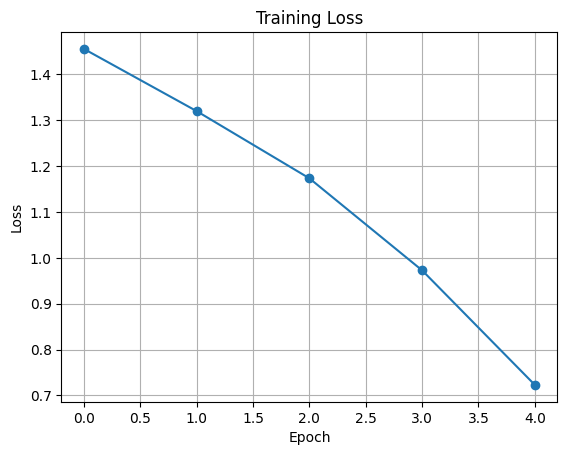

In [7]:
plt.plot(losses, marker="o")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Training Loss")
plt.grid()
plt.show()

## 6. Show Prediction

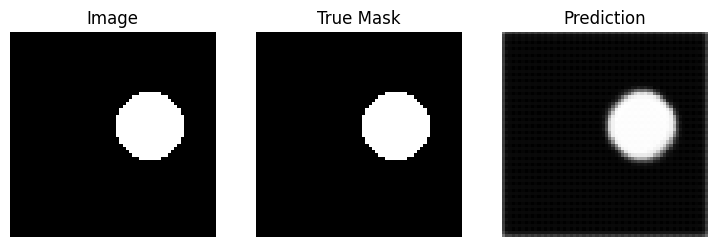

In [8]:
model.eval()

image, true_mask = dataset[0]

with torch.no_grad():
    pred = model(
        image.unsqueeze(0).to(device)
    )

pred = torch.sigmoid(pred)[0, 0].cpu()

plt.figure(figsize=(9, 3))

plt.subplot(1, 3, 1)
plt.imshow(image.permute(1, 2, 0))
plt.title("Image")
plt.axis("off")

plt.subplot(1, 3, 2)
plt.imshow(true_mask[0], cmap="gray")
plt.title("True Mask")
plt.axis("off")

plt.subplot(1, 3, 3)
plt.imshow(pred, cmap="gray")
plt.title("Prediction")
plt.axis("off")

plt.show()

## 7. Pixel-wise Precision-Recall Curve

We test different thresholds and calculate precision and recall for every pixel.

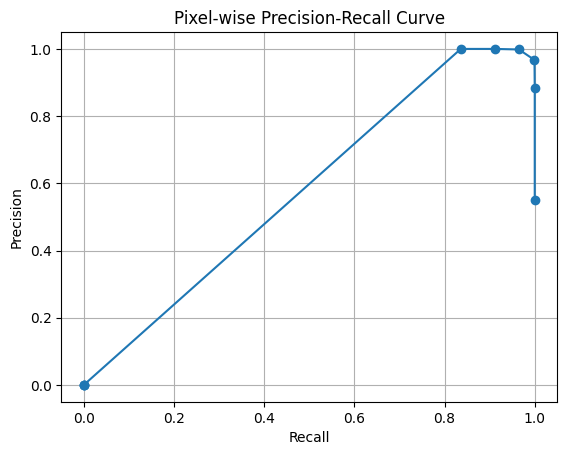

In [9]:
all_pred = []
all_true = []

with torch.no_grad():

    for images, masks in loader:

        output = model(
            images.to(device)
        )

        prob = torch.sigmoid(output).cpu().numpy()

        all_pred.extend(prob.flatten())
        all_true.extend(masks.numpy().flatten())


all_pred = np.array(all_pred)
all_true = np.array(all_true)

precision = []
recall = []

for threshold in np.linspace(0.1, 0.9, 9):

    p = all_pred >= threshold
    t = all_true >= 0.5

    tp = np.sum(p & t)
    fp = np.sum(p & ~t)
    fn = np.sum(~p & t)

    precision.append(
        tp / (tp + fp + 1e-8)
    )

    recall.append(
        tp / (tp + fn + 1e-8)
    )


plt.plot(
    recall,
    precision,
    marker="o"
)

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Pixel-wise Precision-Recall Curve")
plt.grid()
plt.show()